# Tests for variation methods
Methods (in `variation_methods.py`)
- `generate_densify_variant`
- `generate_equalize_variant`

# Setup

## Imports

In [1]:
import sys
import os
# Add the project root to sys.path to allow imports from src
project_root = os.path.abspath(os.path.join(os.getcwd(), '../../'))
if project_root not in sys.path:
    sys.path.append(project_root)

In [2]:
import sys
import os

# Add utils directory to path to allow imports of variation_methods and network_utils
# and to let them find their local dependencies (imports.py)
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../utils")))

import dill

import networkx as nx
import pandas as pd
import seaborn as sns
import numpy.random as rd
import statsmodels.api as sm
import matplotlib.pyplot as plt

from IPython.display import display
from joblib import Parallel, delayed
from statsmodels.stats.outliers_influence import variance_inflation_factor
from tqdm.auto import tqdm

from networks.variation_methods import generate_densify_variant, generate_equalize_variant
from networks.network_utils import network_statistics

## Methods for assessing multicollinearity based on VIF and Pearson correlations

In [ ]:
def VIF_interpretation(score: float) -> str:
    if score >= 5:
        return "high multicollinearity"
    elif score > 1.5:
        return "acceptable multicollinearity"
    elif score > 1:
        return "minimal multicollinearity"
    elif score == 1:
        return "no multicollinearity"
    else:
        return "something went wrong"


def compute_vif(
    df: pd.DataFrame,
    columns_corr: list[str] = ["degree_average", "degree_gini", "clustering_average"],
):
    X = df[columns_corr].copy()
    X_const = X
    X_const = sm.add_constant(X)

    vif_data = pd.DataFrame(
        {
            "variable": X_const.columns,
            "VIF": [
                variance_inflation_factor(X_const.values, i)
                for i in range(X_const.shape[1])
            ],
            "VIF interpretation": [
                VIF_interpretation(variance_inflation_factor(X_const.values, i))
                for i in range(X_const.shape[1])
            ],
        }
    )
    vif_df = pd.DataFrame(
        vif_data, 
        columns=["variable", "VIF", "VIF interpretation"])
    vif_df = vif_df[vif_df["variable"].isin(columns_corr)]
    return vif_df

def pearson_interpretation(
      score: float
) -> str:
    score_abs = abs(score)
    if score_abs <= 0.1:
        return "insignificant"
    elif score_abs <= 0.3:
        return "weak"
    elif score_abs <= 0.5:
        return "medium"
    elif score_abs <= 1:
        return "strong"
    else:
        return "error"

def compute_correlations(
    df: pd.DataFrame, 
    columns_corr = ["degree_average", "degree_gini",'clustering_average'],
):
    df_corr = df[columns_corr].corr(method='pearson')
    display(df_corr)
    df_corr_interpretation = df_corr.map(pearson_interpretation)
    display(df_corr_interpretation)

## Method to generate a dataframe with network variants

In [4]:
def generate_variant_info(
    net: nx.DiGraph, 
    method: str, 
    p_conditional: float = 1.0,
    interim_clustering: bool = True, 
    rewiring_tolerance: float = 0.0,
    max_post_rewires: int = 0, 
    target_clustering_std: float = 1.0,
    max_p_edges: float = 1/3,
):
    proportion_edges = max_p_edges * rd.rand()
    n_edges = int(proportion_edges * net.number_of_edges())
    kwargs = dict(
        p_conditional=p_conditional, 
        interim_clustering=interim_clustering,
        rewiring_tolerance=rewiring_tolerance, 
        max_post_rewires=max_post_rewires,
    )
    if "equal" in method:
        net_variant, n_clustering_edges, n_degree_edges, n_post_rewires = generate_equalize_variant(net, n_edges, **kwargs)
    elif "dens" in method:
        net_clustering = network_statistics(net)["approx_average_clustering_coefficient"]
        target_clustering = net_clustering + rd.normal(0, float(target_clustering_std))
        kwargs["target_clustering"] = target_clustering
        net_variant, n_clustering_edges, n_degree_edges, n_post_rewires = generate_densify_variant(net, n_edges, **kwargs)
    else:
        raise ValueError(f"Unknown method {method}")

    info = network_statistics(net_variant)
    return {
        "proportion_removed": proportion_edges,
        "average_degree": info["average_degree"],
        "degree_gini": info["degree_gini_coefficient"],
        "clustering": info["approx_average_clustering_coefficient"],
        "n_isolates": len(list(nx.isolates(net_variant))),
        "n_clustering_edges": n_clustering_edges,
        "n_degree_edges": n_degree_edges,
        "n_post_rewires": n_post_rewires,
    }

def variant_study(
    net: nx.DiGraph, 
    method: str, 
    n_simulations: int, 
    p_conditional: float = 1.0,
    interim_clustering: bool = True, 
    rewiring_tolerance: float = 0.0,
    max_post_rewires: int = 0, 
    max_p_edges: float = 1/3, 
    target_clustering_std: float = 1.0,
):
    study_params = [{
        "net": net, 
        "method": method, 
        "p_conditional": p_conditional,
        "interim_clustering": interim_clustering, 
        "rewiring_tolerance": rewiring_tolerance,
        "max_post_rewires": max_post_rewires, 
        "max_p_edges": max_p_edges, 
        "target_clustering_std": target_clustering_std
    } for _ in range(n_simulations)]
    data = list(tqdm(Parallel(return_as="generator", n_jobs=-2)(
        delayed(generate_variant_info)(**params)
        for params in study_params
    ), total=n_simulations, desc="Progress"))
    return pd.DataFrame(data)

## Methods for testing equalize and densify

In [5]:
def _sort_for_stacked_bar(df: pd.DataFrame) -> pd.DataFrame:
    totals = df[["n_degree_edges", "n_clustering_edges"]].sum(axis=1).replace(0, 1)
    df = df.copy()
    df["_p_degree"]     = df["n_degree_edges"]       / totals
    df["_p_clustering"] = df["n_clustering_edges"]   / totals
    secondary = "_p_clustering"

    df = df.sort_values(["_p_degree", secondary], ascending=False).reset_index(drop=True)
    return df.drop(columns=["_p_degree", "_p_clustering"])


def _stacked_edge_bar(df: pd.DataFrame) -> None:
    df_sorted = _sort_for_stacked_bar(df)
    totals = df_sorted[["n_degree_edges", "n_clustering_edges"]].sum(axis=1).replace(0, 1)
    p_degree     = df_sorted["n_degree_edges"]       / totals
    p_clustering = df_sorted["n_clustering_edges"]   / totals
    x = range(len(df_sorted))
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(x, p_degree,                                   label="degree",       color="steelblue")
    ax.bar(x, p_clustering, bottom=p_degree,              label="clustering",   color="darkorange")
    ax.set_ylim(0, 1)
    ax.set_ylabel("proportion of edges added")
    ax.set_xlabel("variant (ordered lexicographically by proportion)")
    ax.legend()
    plt.tight_layout()
    plt.show()


def test_equalize(
    net: nx.DiGraph, 
    p_conditional: float = 1.0,
    interim_clustering: bool = True, 
    rewiring_tolerance: float = 0.0,
    max_post_rewires: int = 0, 
    max_p_edges: float = 1/3, 
    target_clustering_std: float = 0.0, 
    n_variants: int = 1_000,
    **kwargs,
):
    # max_post_rewires = int(max_p_post_rewires * net.number_of_edges())
    df_equalize = variant_study(
        net, 
        "equalize", 
        n_variants, 
        p_conditional=p_conditional,
        interim_clustering=interim_clustering, 
        rewiring_tolerance=rewiring_tolerance,
        max_post_rewires=max_post_rewires, 
        max_p_edges=max_p_edges, 
        target_clustering_std=target_clustering_std,
    )
    network_features = ["degree_gini", "clustering"]
    print("Pearson correlations. The result should be: all weak (except diagonal)")
    print("-"*50)
    correlations = compute_correlations(df_equalize, columns_corr=network_features)
    print("VIF. The result should be: all minimal multicollinearity")
    print("-"*50)
    display(compute_vif(df_equalize, columns_corr=network_features))
    print("Scatterplot. Figure should not indicate any relation between the network features.")
    net_stats = network_statistics(net)
    plt.figure()
    sns.scatterplot(df_equalize, x="clustering", y="degree_gini")
    plt.scatter(net_stats["approx_average_clustering_coefficient"], net_stats["degree_gini_coefficient"], color="red", zorder=5)
    plt.show()
    if interim_clustering:
        _stacked_edge_bar(df_equalize)
    plt.figure()
    sns.scatterplot(df_equalize, x="n_post_rewires", y="clustering")
    plt.show()
    print("No isolates check. The result should be: True")
    print(all(x == 0 for x in df_equalize["n_isolates"]))


def test_densify(
    net: nx.DiGraph, 
    p_conditional: float = 1.0,
    interim_clustering: bool = True, 
    rewiring_tolerance: float = 0.0,
    max_post_rewires: int = 0, 
    max_p_edges: float = 1/3, 
    target_clustering_std: float = 0.0, 
    n_variants: int = 1_000,
    **kwargs,
):
    # max_post_rewires = int(max_p_post_rewires * net.number_of_edges())
    df_densify = variant_study(
        net, 
        "densify", 
        n_variants, 
        p_conditional=p_conditional,
        interim_clustering=interim_clustering, 
        rewiring_tolerance=rewiring_tolerance,
        max_post_rewires=max_post_rewires, 
        max_p_edges=max_p_edges, 
        target_clustering_std=target_clustering_std,
    )
    network_features = ["average_degree", "degree_gini", "clustering"]
    print("Pearson correlations. The result should be: all weak (except diagonal)")
    print("-"*50)
    correlations = compute_correlations(df_densify, columns_corr=network_features)
    print("VIF. The result should be: all minimal multicollinearity")
    print("-"*50)
    display(compute_vif(df_densify, columns_corr=network_features))
    print("Scatterplots. Figure should not indicate any relation between the network features.")
    net_stats = network_statistics(net)
    plt.figure()
    sns.scatterplot(df_densify, x="average_degree", y="degree_gini")
    plt.scatter(net_stats["average_degree"], net_stats["degree_gini_coefficient"], color="red", zorder=5)
    plt.figure()
    sns.scatterplot(df_densify, x="average_degree", y="clustering")
    plt.scatter(net_stats["average_degree"], net_stats["approx_average_clustering_coefficient"], color="red", zorder=5)
    plt.show()
    if interim_clustering:
        _stacked_edge_bar(df_densify)
    plt.figure()
    sns.scatterplot(df_densify, x="n_post_rewires", y="clustering")
    plt.show()
    print("No isolates check. The result should be: True")
    print(all(x == 0 for x in df_densify["n_isolates"]))

# Testing networks

## Load networks

In [6]:
with open('../../networks/citation_data/pud_network.pkl', 'rb') as f:
    pud_net = dill.load(f)

print(f"{pud_net.number_of_nodes()=:,}")
print(f"{pud_net.number_of_edges()=:,}")
display(network_statistics(pud_net))

pud_net.number_of_nodes()=90
pud_net.number_of_edges()=160


{'average_degree': 1.7777777777777777,
 'degree_gini_coefficient': 0.7245833333333334,
 'approx_average_clustering_coefficient': 0.16390694750343873}

In [7]:
with open('../../networks/citation_data/ego_network.pkl', 'rb') as f:
    ego_net = dill.load(f)

print(f"{ego_net.number_of_nodes()=:,}")
print(f"{ego_net.number_of_edges()=:,}")
display(network_statistics(ego_net))

ego_net.number_of_nodes()=503
ego_net.number_of_edges()=2,933


{'average_degree': 5.831013916500994,
 'degree_gini_coefficient': 0.9204303669967918,
 'approx_average_clustering_coefficient': 0.5937396382121215}

In [8]:
with open('../../networks/citation_data/tobacco_network.pkl', 'rb') as f:
    tobacco_net = dill.load(f)

print(f"{tobacco_net.number_of_nodes()=:,}")
print(f"{tobacco_net.number_of_edges()=:,}")
display(network_statistics(tobacco_net))

tobacco_net.number_of_nodes()=289
tobacco_net.number_of_edges()=1,229


{'average_degree': 4.252595155709343,
 'degree_gini_coefficient': 0.7613132459225015,
 'approx_average_clustering_coefficient': 0.23497312210774274}

## PUD

### Densify

Progress:   0%|          | 0/1000 [00:00<?, ?it/s]

Pearson correlations. The result should be: all weak (except diagonal)
--------------------------------------------------


,average_degree,degree_gini,clustering
average_degree,1.000000,0.047495,0.078616
degree_gini,0.047495,1.000000,0.004855
clustering,0.078616,0.004855,1.000000


,average_degree,degree_gini,clustering
average_degree,strong,weak,weak
degree_gini,weak,strong,weak
clustering,weak,weak,strong


VIF. The result should be: all minimal multicollinearity
--------------------------------------------------


,variable,VIF,VIF interpretation
1,average_degree,1.008471,minimal multicollinearity
2,degree_gini,1.002262,minimal multicollinearity
3,clustering,1.006220,minimal multicollinearity


Scatterplots. Figure should not indicate any relation between the network features.


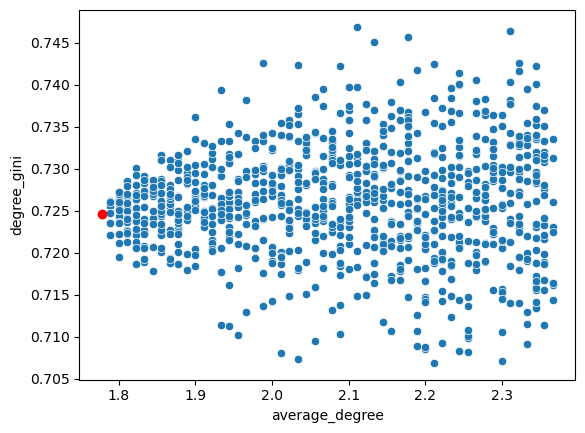

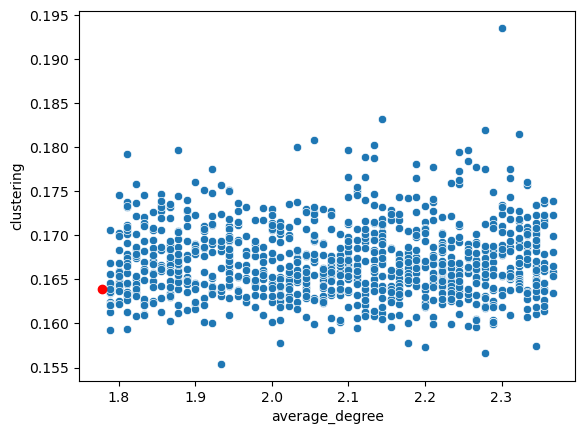

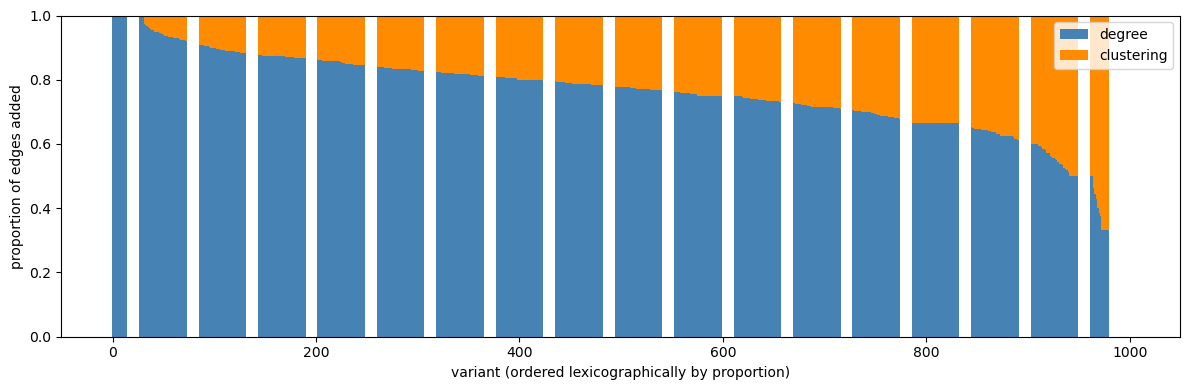

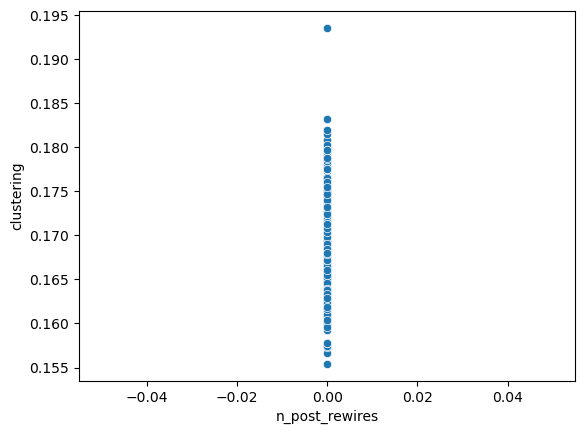

No isolates check. The result should be: True
True


In [16]:
test_densify(
    pud_net, 
    p_conditional=0.0, 
    interim_clustering=True, 
    max_post_rewires=0, 
    n_variants=1_000,
)

Progress:   0%|          | 0/1000 [00:00<?, ?it/s]

Pearson correlations. The result should be: all weak (except diagonal)
--------------------------------------------------


,average_degree,degree_gini,clustering
average_degree,1.000000,-0.016963,-0.106391
degree_gini,-0.016963,1.000000,-0.020547
clustering,-0.106391,-0.020547,1.000000


,average_degree,degree_gini,clustering
average_degree,strong,weak,weak
degree_gini,weak,strong,weak
clustering,weak,weak,strong


VIF. The result should be: all minimal multicollinearity
--------------------------------------------------


,variable,VIF,VIF interpretation
1,average_degree,1.011824,minimal multicollinearity
2,degree_gini,1.000794,minimal multicollinearity
3,clustering,1.011960,minimal multicollinearity


Scatterplots. Figure should not indicate any relation between the network features.


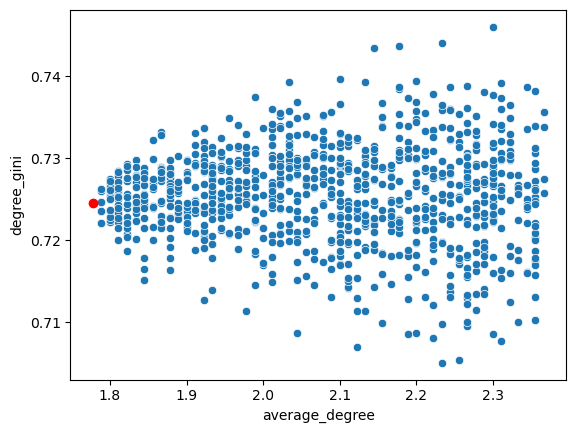

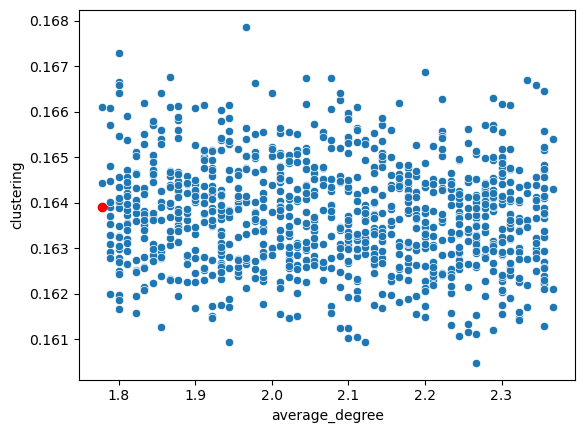

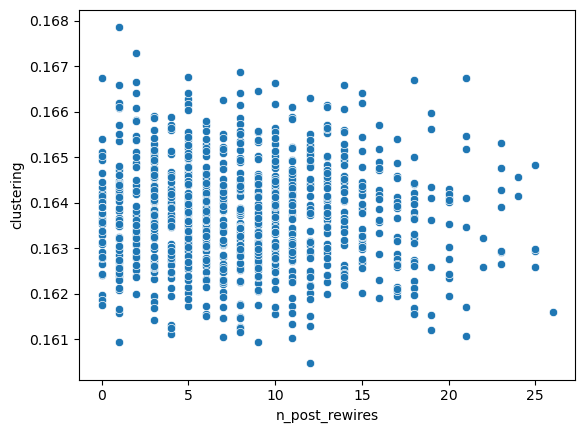

No isolates check. The result should be: True
True


In [9]:
test_densify(
    pud_net,
    p_conditional=0.0, 
    interim_clustering=False, 
    rewiring_tolerance=0.001,
    max_post_rewires=1_000,
    n_variants=1_000,
    max_p_edges=1/3,
    target_clustering_std=0.001,
)

### Equalize

Progress:   0%|          | 0/1000 [00:00<?, ?it/s]

Pearson correlations. The result should be: all weak (except diagonal)
--------------------------------------------------


,degree_gini,clustering
degree_gini,1.00000,-0.11202
clustering,-0.11202,1.00000


,degree_gini,clustering
degree_gini,strong,weak
clustering,weak,strong


VIF. The result should be: all minimal multicollinearity
--------------------------------------------------


,variable,VIF,VIF interpretation
1,degree_gini,1.012708,minimal multicollinearity
2,clustering,1.012708,minimal multicollinearity


Scatterplot. Figure should not indicate any relation between the network features.


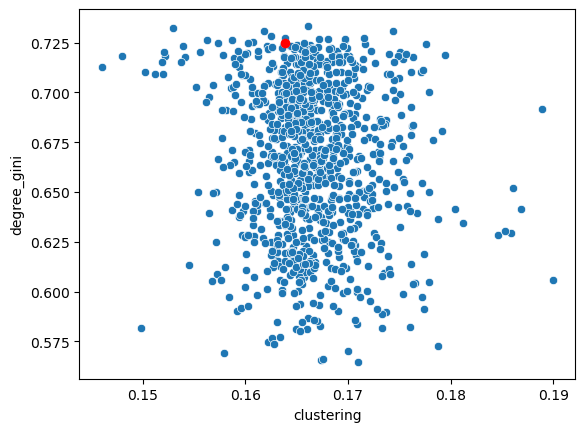

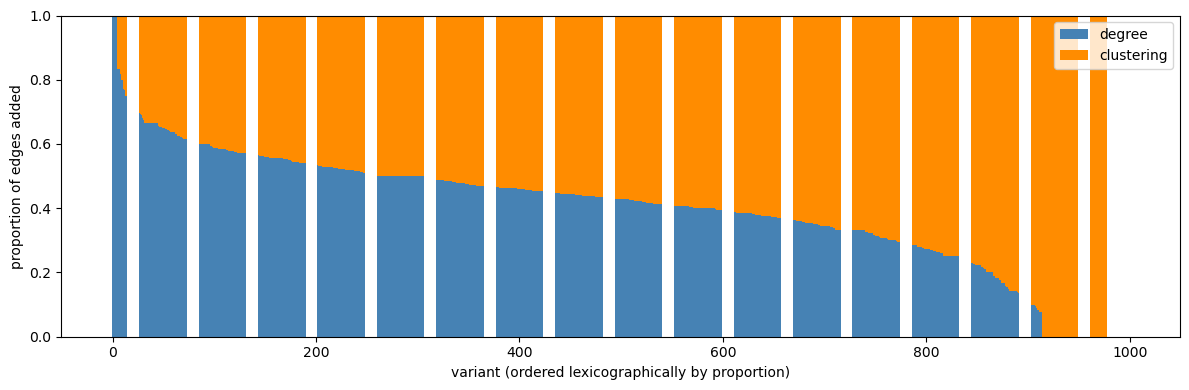

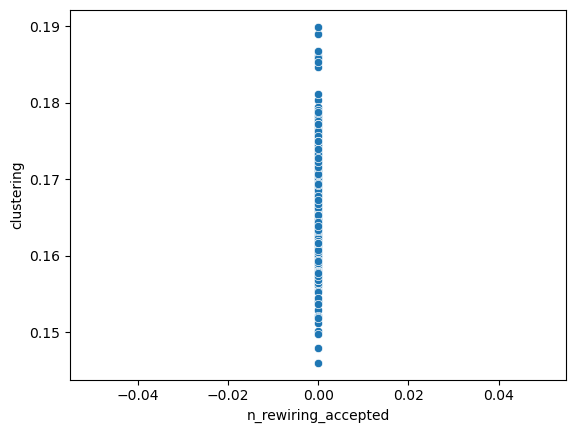

No isolates check. The result should be: True
True


In [ ]:
test_equalize(
    pud_net, 
    p_conditional=0.0, 
    interim_clustering=True, 
    rewiring_tolerance=0.0,
    max_post_rewires=0, 
    n_variants=1_000)

Progress:   0%|          | 0/1000 [00:00<?, ?it/s]

Pearson correlations. The result should be: all weak (except diagonal)
--------------------------------------------------


,degree_gini,clustering
degree_gini,1.000000,0.019222
clustering,0.019222,1.000000


,degree_gini,clustering
degree_gini,strong,weak
clustering,weak,strong


VIF. The result should be: all minimal multicollinearity
--------------------------------------------------


,variable,VIF,VIF interpretation
1,degree_gini,1.00037,minimal multicollinearity
2,clustering,1.00037,minimal multicollinearity


Scatterplot. Figure should not indicate any relation between the network features.


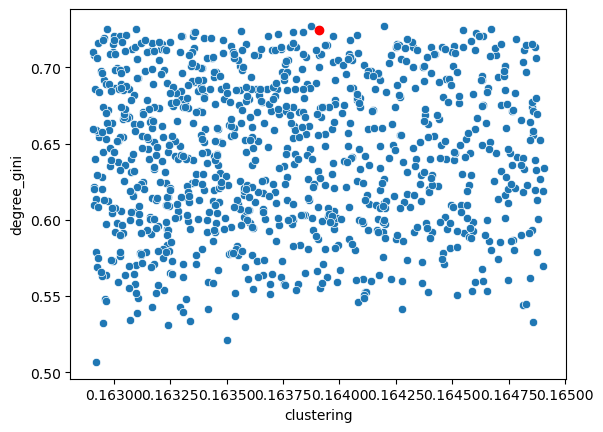

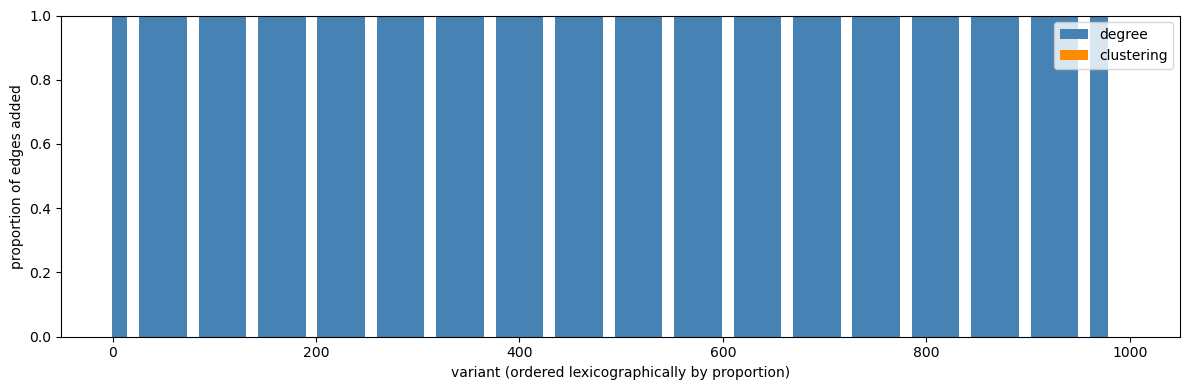

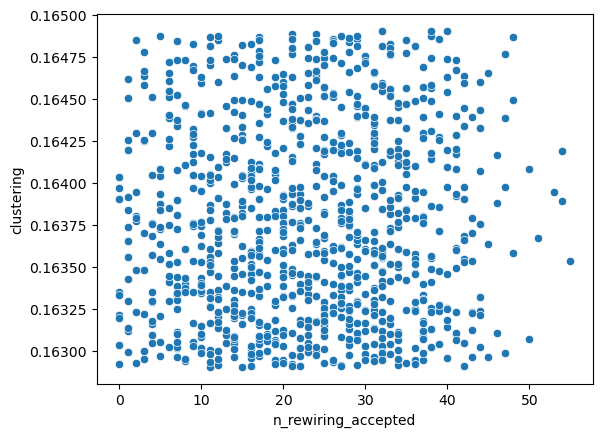

No isolates check. The result should be: True
True


In [ ]:
test_equalize(
    pud_net, 
    p_conditional=0.0, 
    interim_clustering=False, 
    rewiring_tolerance=0.001,
    max_post_rewires=1_000, 
    n_variants=1_000,
    max_p_edges=1/3,
    target_clustering_std=0.001,)

Progress:   0%|          | 0/1000 [00:00<?, ?it/s]

Pearson correlations. The result should be: all weak (except diagonal)
--------------------------------------------------


,degree_gini,clustering
degree_gini,1.000000,0.042112
clustering,0.042112,1.000000


,degree_gini,clustering
degree_gini,strong,weak
clustering,weak,strong


VIF. The result should be: all minimal multicollinearity
--------------------------------------------------


,variable,VIF,VIF interpretation
1,degree_gini,1.001777,minimal multicollinearity
2,clustering,1.001777,minimal multicollinearity


Scatterplot. Figure should not indicate any relation between the network features.


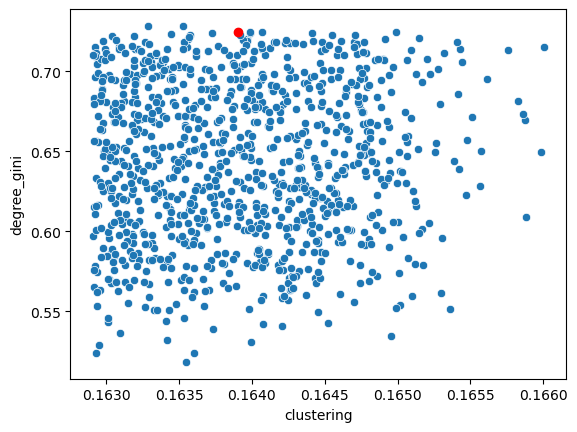

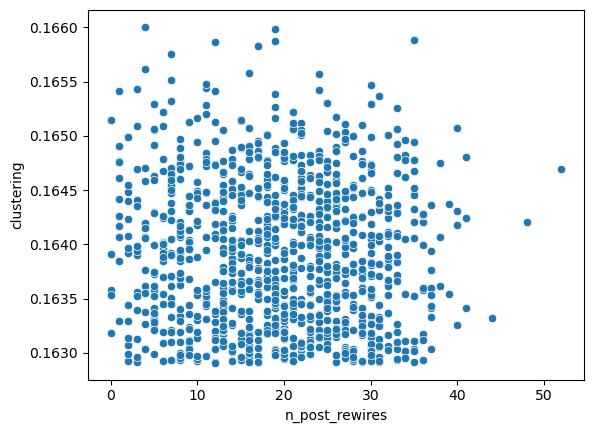

No isolates check. The result should be: True
True


In [12]:
test_equalize(
    pud_net, 
    p_conditional=0.0, 
    interim_clustering=False, 
    rewiring_tolerance=0.001,
    max_post_rewires=1_000, 
    n_variants=1_000,
    max_p_edges=1/3,
    target_clustering_std=0.001,)

## Ego depletion

### Densify

Progress:   0%|          | 0/1000 [00:00<?, ?it/s]

Pearson correlations. The result should be: all weak (except diagonal)
--------------------------------------------------


,average_degree,degree_gini,clustering
average_degree,1.000000,0.291769,0.594290
degree_gini,0.291769,1.000000,0.355476
clustering,0.594290,0.355476,1.000000


,average_degree,degree_gini,clustering
average_degree,strong,weak,strong
degree_gini,weak,strong,medium
clustering,strong,medium,strong


VIF. The result should be: all minimal multicollinearity
--------------------------------------------------


,variable,VIF,VIF interpretation
1,average_degree,1.563969,acceptable multicollinearity
2,degree_gini,1.157924,minimal multicollinearity
3,clustering,1.637786,acceptable multicollinearity


Scatterplots. Figure should not indicate any relation between the network features.


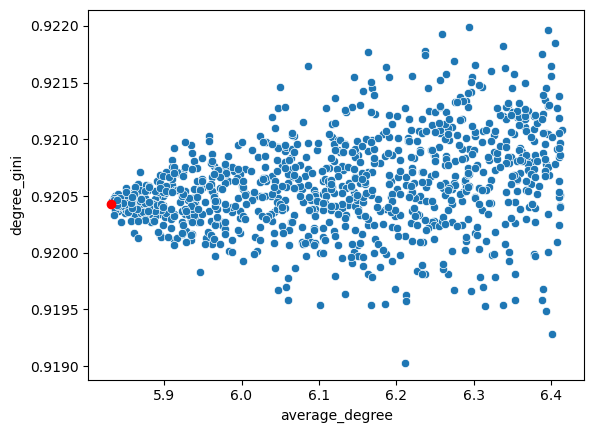

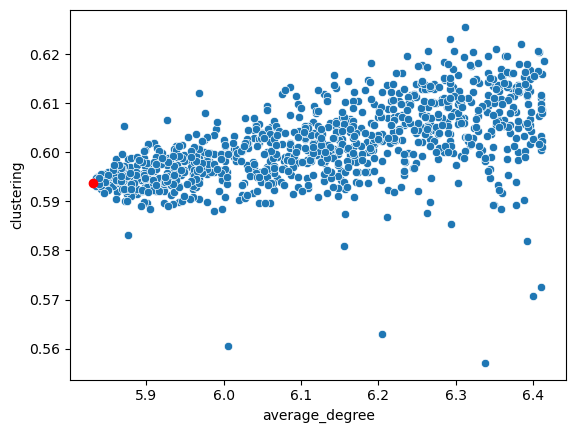

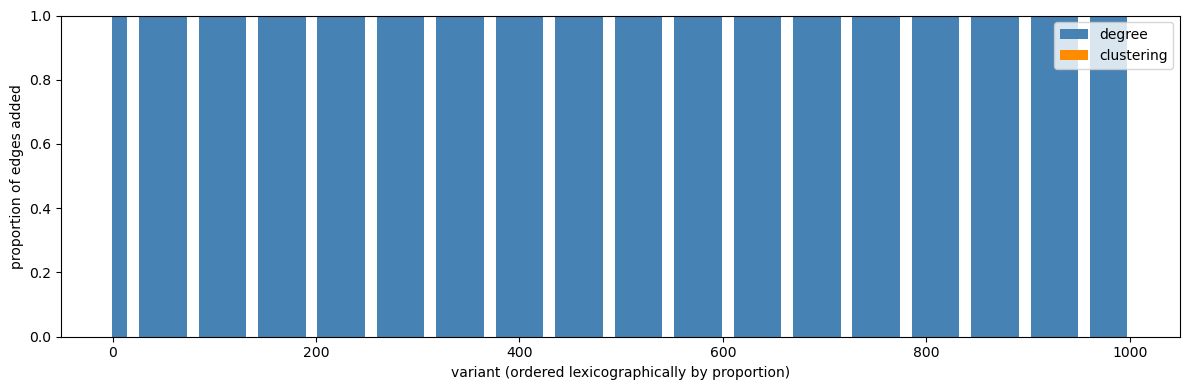

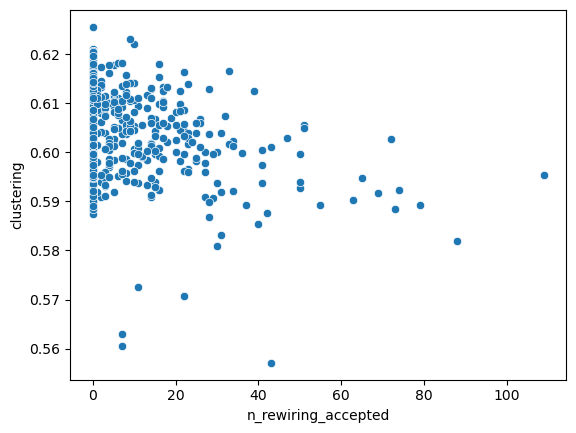

No isolates check. The result should be: True
True


In [ ]:
test_densify(
    ego_net, 
    p_conditional=1.0, 
    interim_clustering=False, 
    rewiring_tolerance=0.02, 
    max_post_rewires=1_000, 
    n_variants=1_000,
    max_p_edges=0.1,
    target_clustering_std=0.01,
)

Progress:   0%|          | 0/1000 [00:00<?, ?it/s]

Pearson correlations. The result should be: all weak (except diagonal)
--------------------------------------------------


,average_degree,degree_gini,clustering
average_degree,1.000000,0.098890,0.012161
degree_gini,0.098890,1.000000,-0.030959
clustering,0.012161,-0.030959,1.000000


,average_degree,degree_gini,clustering
average_degree,strong,weak,weak
degree_gini,weak,strong,weak
clustering,weak,weak,strong


VIF. The result should be: all minimal multicollinearity
--------------------------------------------------


,variable,VIF,VIF interpretation
1,average_degree,1.010112,minimal multicollinearity
2,degree_gini,1.010932,minimal multicollinearity
3,clustering,1.001194,minimal multicollinearity


Scatterplots. Figure should not indicate any relation between the network features.


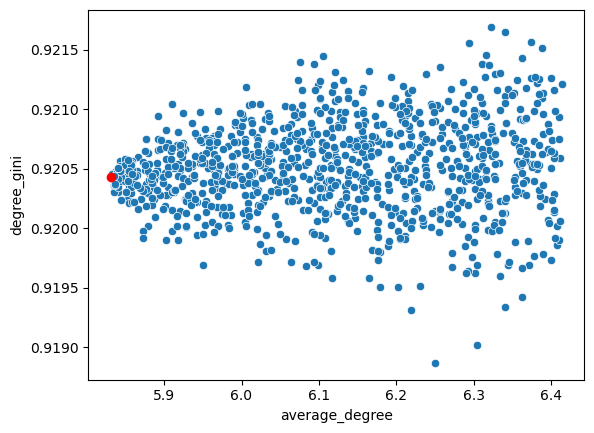

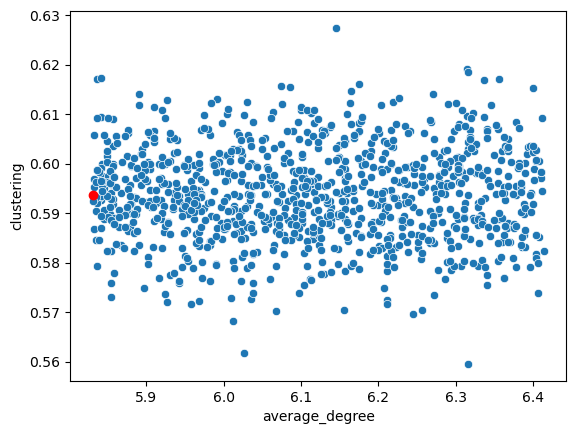

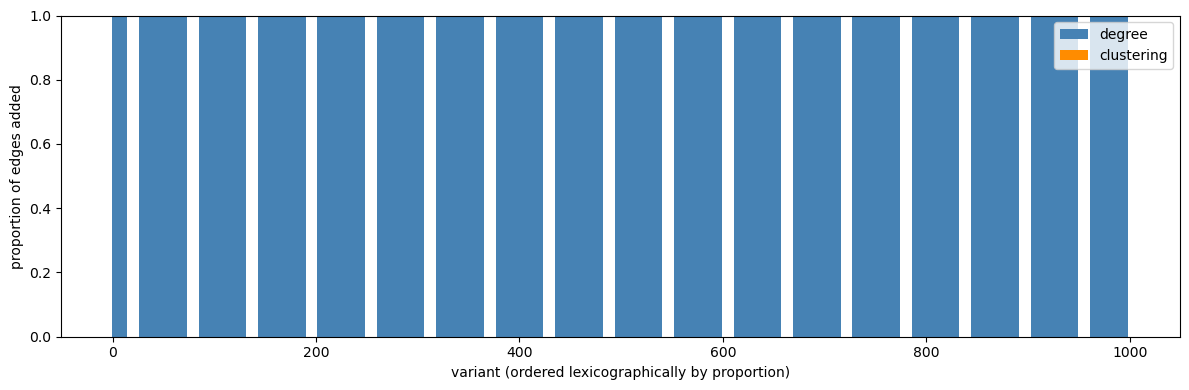

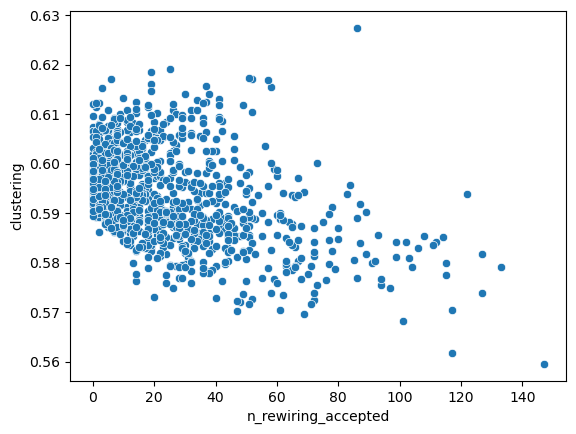

No isolates check. The result should be: True
True


In [ ]:
test_densify(
    ego_net, 
    p_conditional=0.95, 
    interim_clustering=False, 
    rewiring_tolerance=0.001, 
    max_post_rewires=5_000, 
    n_variants=1_000,
    max_p_edges=0.1,
    target_clustering_std=0.01,
)

Progress:   0%|          | 0/1000 [00:00<?, ?it/s]

Pearson correlations. The result should be: all weak (except diagonal)
--------------------------------------------------


,average_degree,degree_gini,clustering
average_degree,1.000000,0.042575,0.012211
degree_gini,0.042575,1.000000,-0.029753
clustering,0.012211,-0.029753,1.000000


,average_degree,degree_gini,clustering
average_degree,strong,weak,weak
degree_gini,weak,strong,weak
clustering,weak,weak,strong


VIF. The result should be: all minimal multicollinearity
--------------------------------------------------


,variable,VIF,VIF interpretation
1,average_degree,1.001998,minimal multicollinearity
2,degree_gini,1.002737,minimal multicollinearity
3,clustering,1.001068,minimal multicollinearity


Scatterplots. Figure should not indicate any relation between the network features.


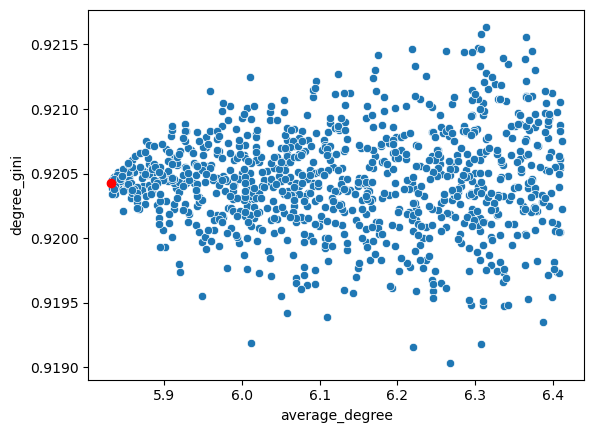

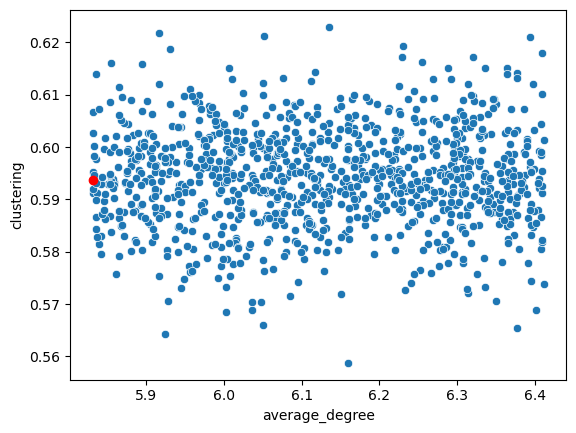

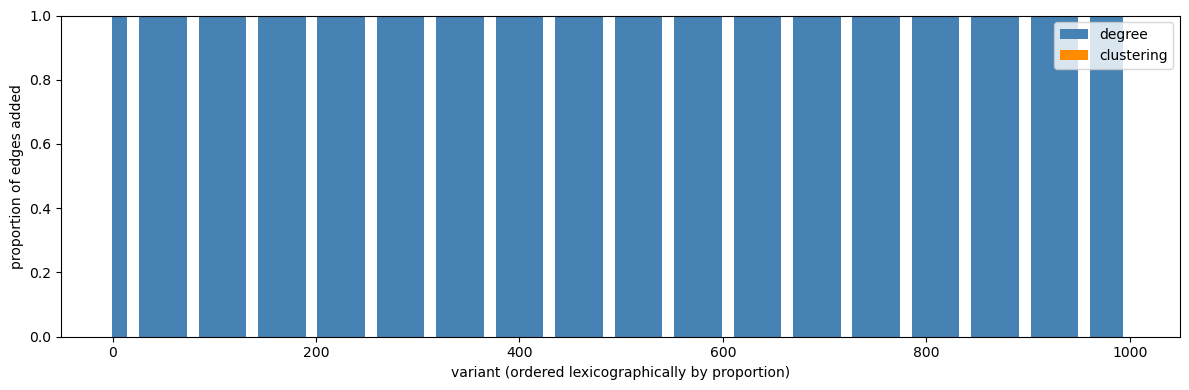

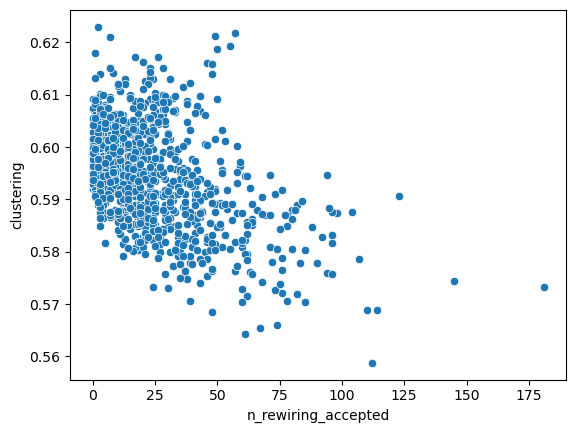

No isolates check. The result should be: True
True


In [ ]:
test_densify(
    ego_net, 
    p_conditional=0.925, 
    interim_clustering=False, 
    rewiring_tolerance=0.001, 
    max_post_rewires=5_000, 
    n_variants=1_000,
    max_p_edges=0.1,
    target_clustering_std=0.01,
)

Progress:   0%|          | 0/1000 [00:00<?, ?it/s]

Pearson correlations. The result should be: all weak (except diagonal)
--------------------------------------------------


,average_degree,degree_gini,clustering
average_degree,1.000000,-0.008743,0.001186
degree_gini,-0.008743,1.000000,0.030493
clustering,0.001186,0.030493,1.000000


,average_degree,degree_gini,clustering
average_degree,strong,weak,weak
degree_gini,weak,strong,weak
clustering,weak,weak,strong


VIF. The result should be: all minimal multicollinearity
--------------------------------------------------


,variable,VIF,VIF interpretation
1,average_degree,1.000079,minimal multicollinearity
2,degree_gini,1.001008,minimal multicollinearity
3,clustering,1.000933,minimal multicollinearity


Scatterplots. Figure should not indicate any relation between the network features.


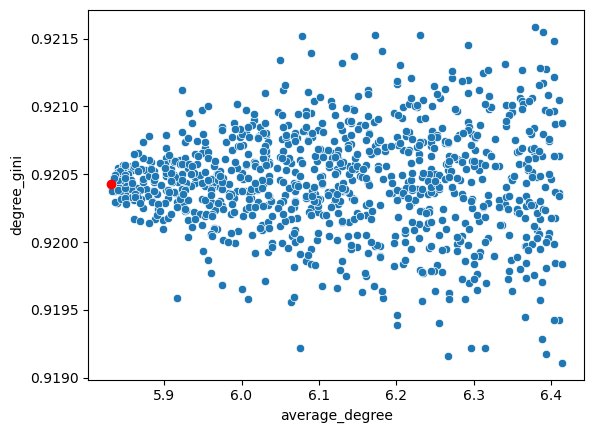

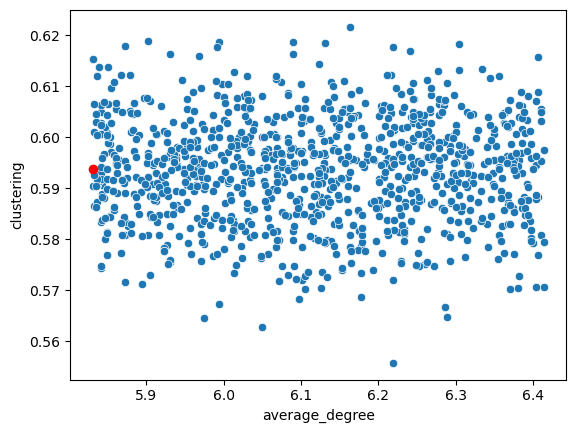

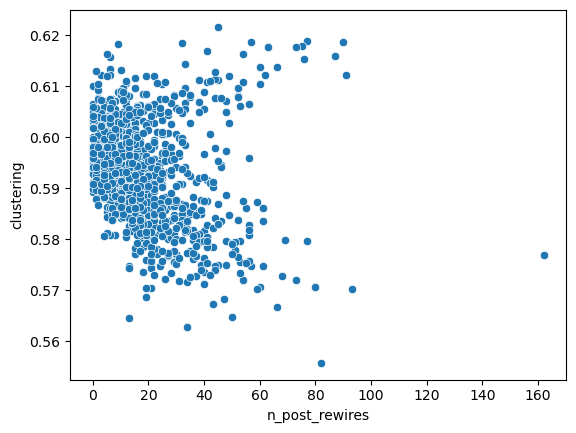

No isolates check. The result should be: True
True


In [14]:
test_densify(
    ego_net, 
    p_conditional=0.925, 
    interim_clustering=False, 
    rewiring_tolerance=0.001, 
    max_post_rewires=5_000, 
    n_variants=1_000,
    max_p_edges=0.1,
    target_clustering_std=0.01,
)

### Equalize

Progress:   0%|          | 0/100 [00:00<?, ?it/s]

Pearson correlations. The result should be: all weak (except diagonal)
--------------------------------------------------


,degree_gini,clustering
degree_gini,1.000000,0.961604
clustering,0.961604,1.000000


,degree_gini,clustering
degree_gini,strong,strong
clustering,strong,strong


VIF. The result should be: all minimal multicollinearity
--------------------------------------------------


,variable,VIF,VIF interpretation
1,degree_gini,13.277123,high multicollinearity
2,clustering,13.277123,high multicollinearity


Scatterplot. Figure should not indicate any relation between the network features.


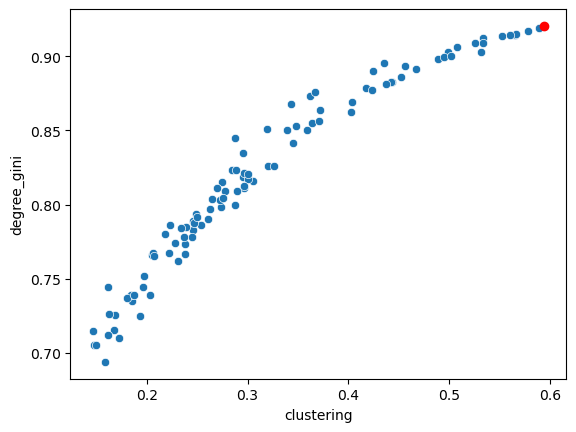

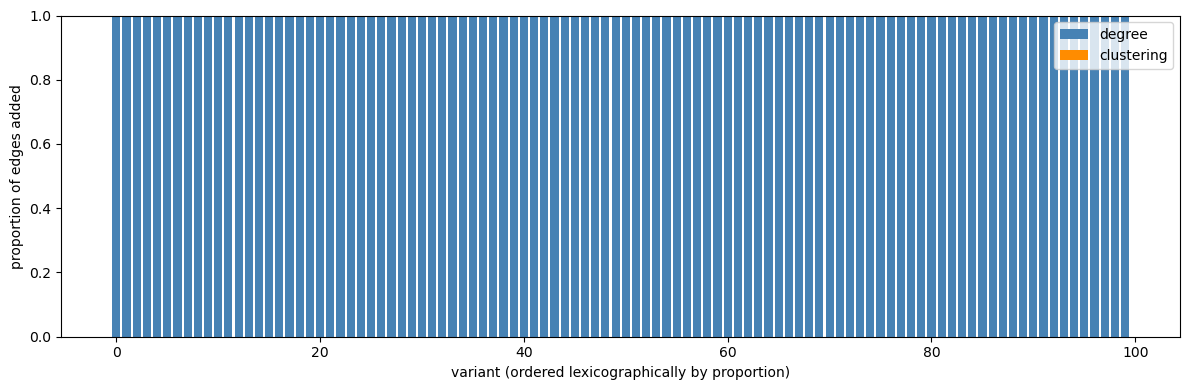

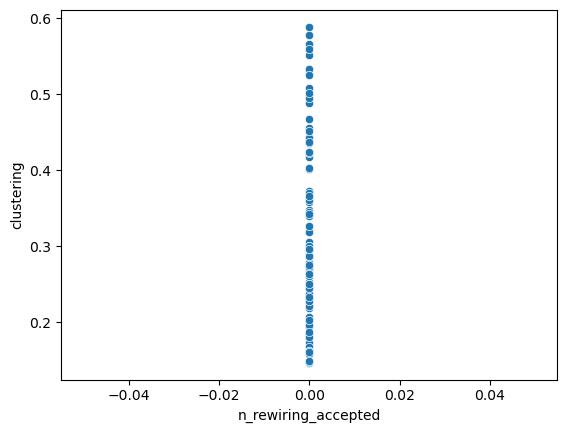

No isolates check. The result should be: True
True


In [ ]:
test_equalize(
    ego_net,
    p_conditional=0.0,
    interim_clustering=False, 
    rewiring_tolerance=0.001, 
    max_post_rewires=0, 
    n_variants=100,
    max_p_edges=1/3,
    target_clustering_std=0.01,
)

Progress:   0%|          | 0/100 [00:00<?, ?it/s]

Pearson correlations. The result should be: all weak (except diagonal)
--------------------------------------------------


,degree_gini,clustering
degree_gini,1.000000,0.609485
clustering,0.609485,1.000000


,degree_gini,clustering
degree_gini,strong,strong
clustering,strong,strong


VIF. The result should be: all minimal multicollinearity
--------------------------------------------------


,variable,VIF,VIF interpretation
1,degree_gini,1.59102,acceptable multicollinearity
2,clustering,1.59102,acceptable multicollinearity


Scatterplot. Figure should not indicate any relation between the network features.


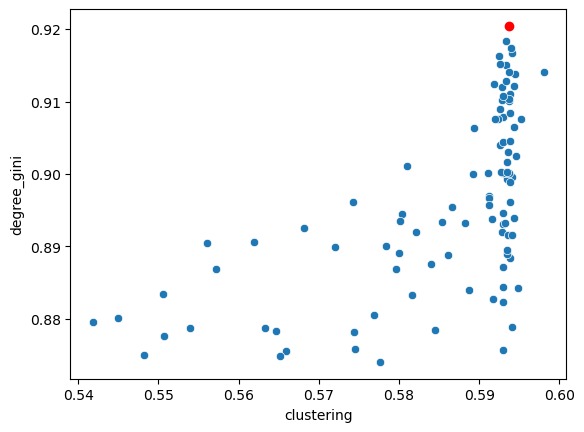

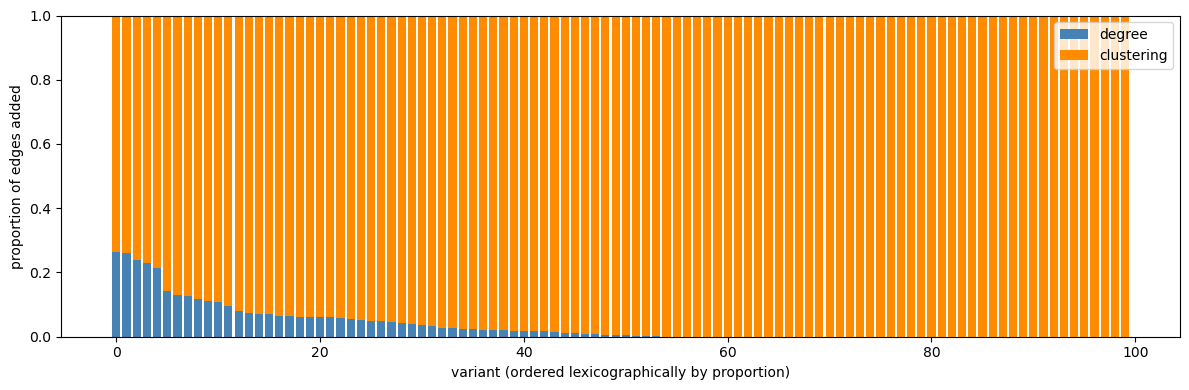

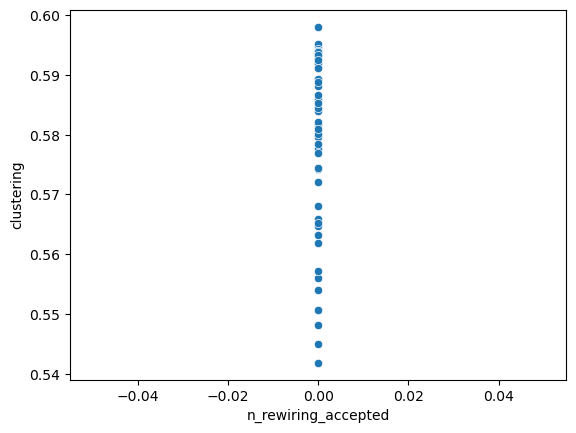

No isolates check. The result should be: True
True


In [ ]:
test_equalize(
    ego_net, 
    p_conditional=0.0,
    interim_clustering=True, 
    rewiring_tolerance=0.001, 
    max_post_rewires=0, 
    n_variants=100,
    max_p_edges=1/3,
    target_clustering_std=0.01,
)

Progress:   0%|          | 0/100 [00:00<?, ?it/s]

Pearson correlations. The result should be: all weak (except diagonal)
--------------------------------------------------


,degree_gini,clustering
degree_gini,1.000000,0.991633
clustering,0.991633,1.000000


,degree_gini,clustering
degree_gini,strong,strong
clustering,strong,strong


VIF. The result should be: all minimal multicollinearity
--------------------------------------------------


,variable,VIF,VIF interpretation
1,degree_gini,60.007226,high multicollinearity
2,clustering,60.007226,high multicollinearity


Scatterplot. Figure should not indicate any relation between the network features.


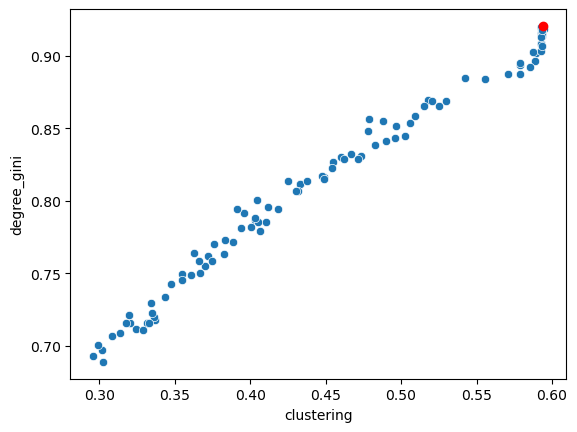

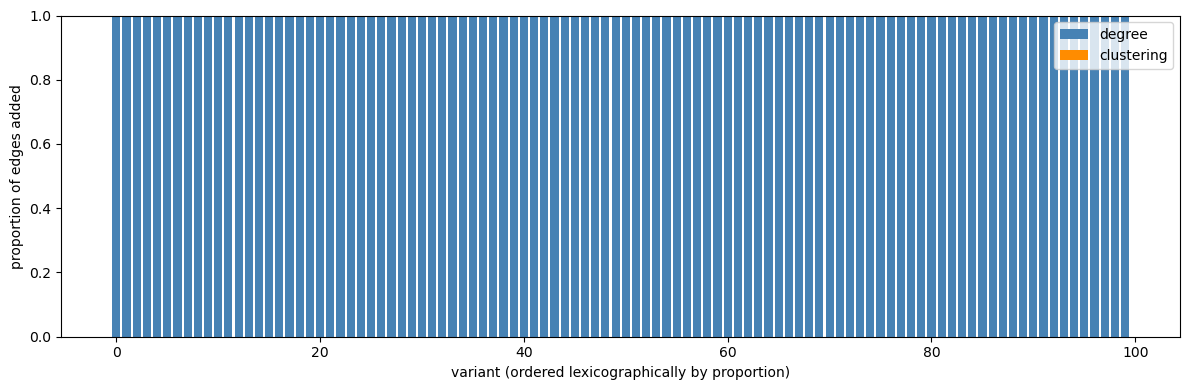

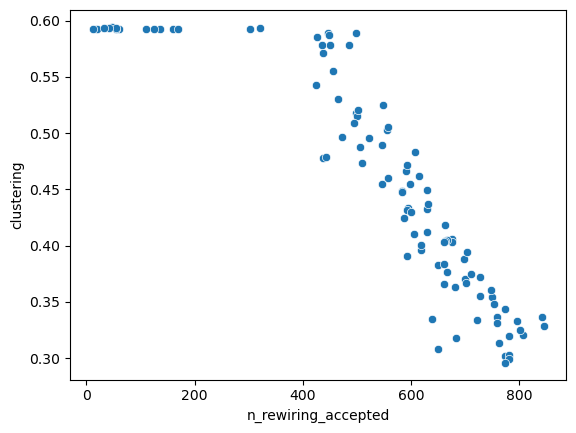

No isolates check. The result should be: True
True


In [ ]:
test_equalize(
    ego_net, 
    p_conditional=0.0,
    interim_clustering=False, 
    rewiring_tolerance=0.001, 
    max_post_rewires=5_000, 
    n_variants=100,
    max_p_edges=1/3,
    target_clustering_std=0.01,
)

Progress:   0%|          | 0/100 [00:00<?, ?it/s]

Pearson correlations. The result should be: all weak (except diagonal)
--------------------------------------------------


,degree_gini,clustering
degree_gini,1.000000,0.937241
clustering,0.937241,1.000000


,degree_gini,clustering
degree_gini,strong,strong
clustering,strong,strong


VIF. The result should be: all minimal multicollinearity
--------------------------------------------------


,variable,VIF,VIF interpretation
1,degree_gini,8.225099,high multicollinearity
2,clustering,8.225099,high multicollinearity


Scatterplot. Figure should not indicate any relation between the network features.


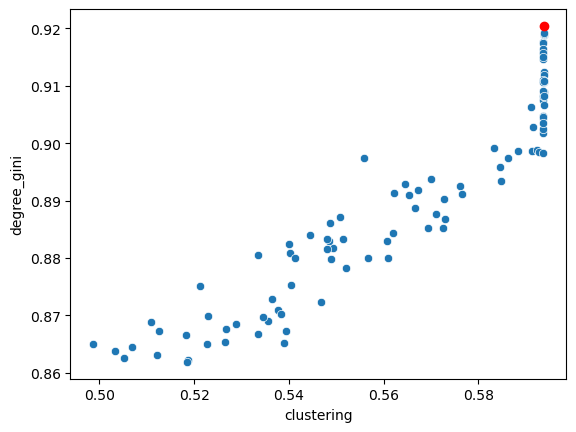

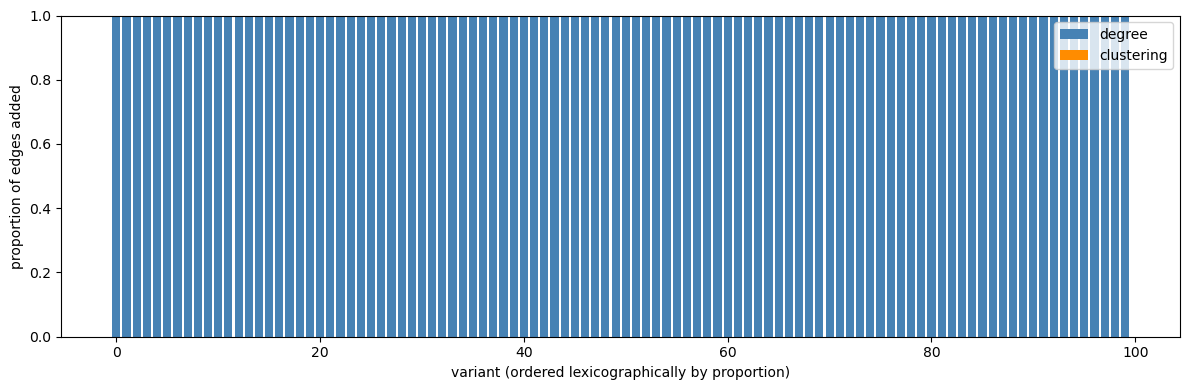

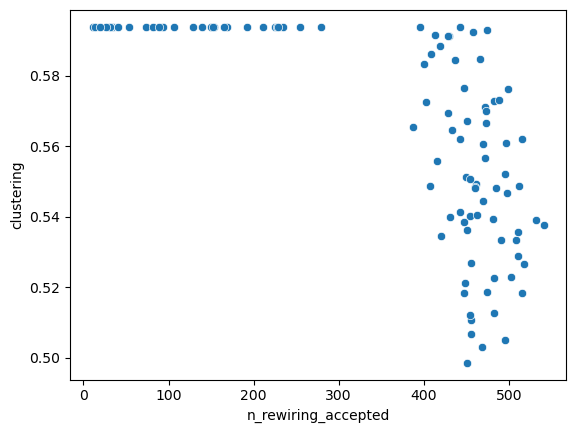

No isolates check. The result should be: True
True


In [ ]:
test_equalize(
    ego_net, 
    p_conditional=0.0,
    interim_clustering=False, 
    rewiring_tolerance=0.0001, # smaller 
    max_post_rewires=5_000, 
    n_variants=100,
    max_p_edges=0.1,
    target_clustering_std=0.01,
)

Progress:   0%|          | 0/100 [00:00<?, ?it/s]

Pearson correlations. The result should be: all weak (except diagonal)
--------------------------------------------------


,degree_gini,clustering
degree_gini,1.000000,0.982962
clustering,0.982962,1.000000


,degree_gini,clustering
degree_gini,strong,strong
clustering,strong,strong


VIF. The result should be: all minimal multicollinearity
--------------------------------------------------


,variable,VIF,VIF interpretation
1,degree_gini,29.598251,high multicollinearity
2,clustering,29.598251,high multicollinearity


Scatterplot. Figure should not indicate any relation between the network features.


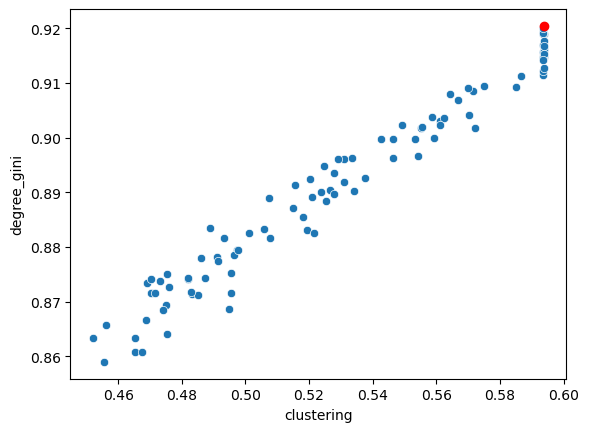

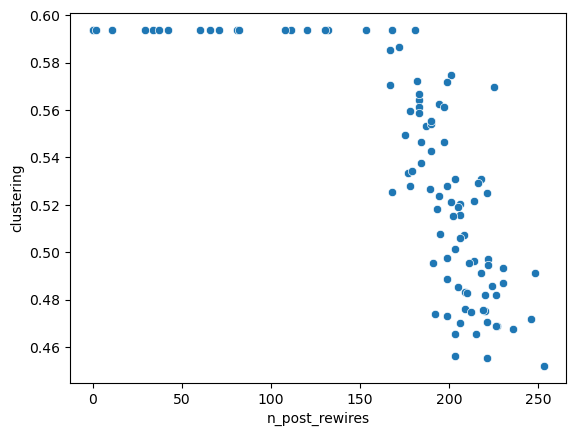

No isolates check. The result should be: True
True


In [15]:
test_equalize(
    ego_net, 
    p_conditional=0.0,
    interim_clustering=False, 
    rewiring_tolerance=0.0001, # smaller 
    max_post_rewires=1_000, 
    n_variants=100,
    max_p_edges=0.1,
    target_clustering_std=0.01,
)

In [16]:
test_equalize(
    ego_net, 
    p_conditional=0.0,
    interim_clustering=False, 
    rewiring_tolerance=0.0001, # smaller 
    max_post_rewires=5_000, 
    n_variants=100,
    max_p_edges=0.1,
    target_clustering_std=0.01,
)

Progress:   0%|          | 0/100 [00:00<?, ?it/s]

KeyboardInterrupt: 

## Tobacco

### Densify

Progress:   0%|          | 0/1000 [00:00<?, ?it/s]

Pearson correlations. The result should be: all weak (except diagonal)
--------------------------------------------------


,average_degree,degree_gini,clustering
average_degree,1.000000,0.056243,0.028093
degree_gini,0.056243,1.000000,0.119856
clustering,0.028093,0.119856,1.000000


,average_degree,degree_gini,clustering
average_degree,strong,weak,weak
degree_gini,weak,strong,weak
clustering,weak,weak,strong


VIF. The result should be: all minimal multicollinearity
--------------------------------------------------


,variable,VIF,VIF interpretation
1,average_degree,1.003639,minimal multicollinearity
2,degree_gini,1.017463,minimal multicollinearity
3,clustering,1.015046,minimal multicollinearity


Scatterplots. Figure should not indicate any relation between the network features.


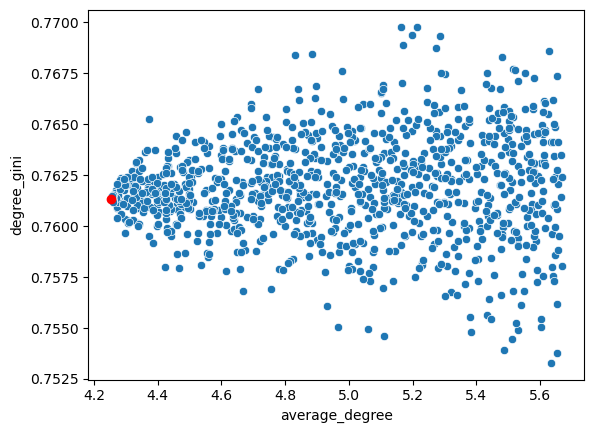

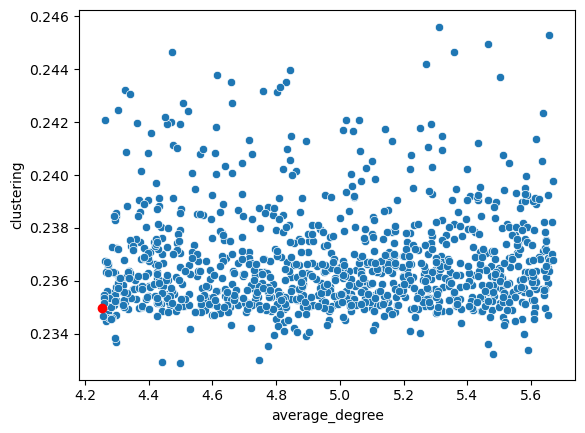

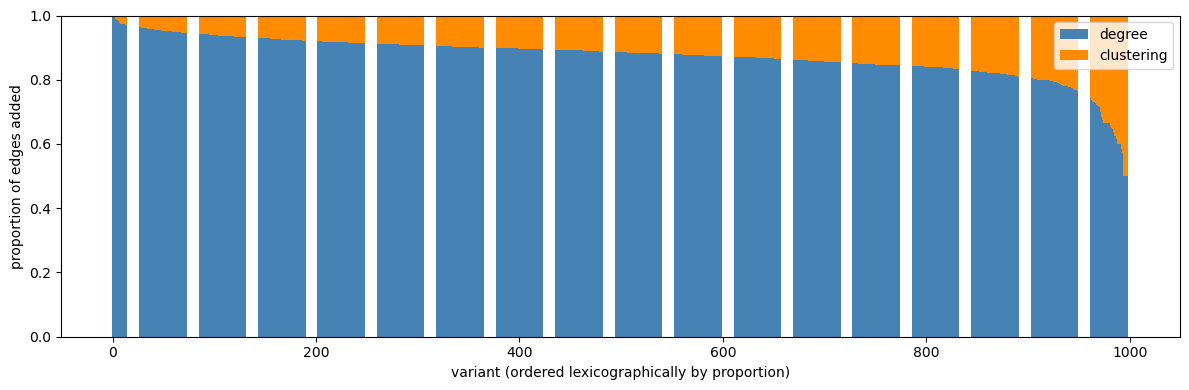

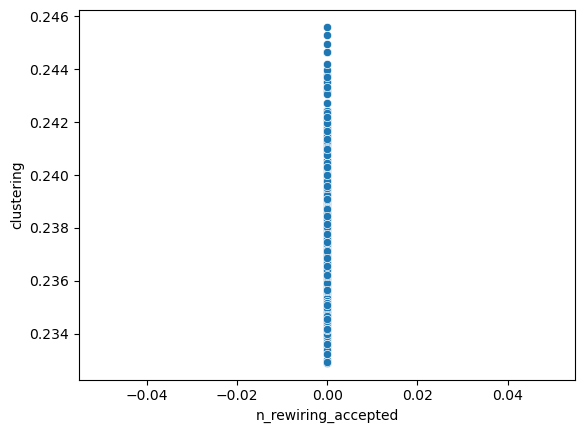

No isolates check. The result should be: True
True


In [ ]:
test_densify(
    tobacco_net, 
    p_conditional=0.5, 
    interim_clustering=True, 
    max_post_rewires=0, 
    n_variants=1_000,
)

Progress:   0%|          | 0/1000 [00:00<?, ?it/s]

Pearson correlations. The result should be: all weak (except diagonal)
--------------------------------------------------


,average_degree,degree_gini,clustering
average_degree,1.000000,-0.214106,0.036407
degree_gini,-0.214106,1.000000,0.008924
clustering,0.036407,0.008924,1.000000


,average_degree,degree_gini,clustering
average_degree,strong,weak,weak
degree_gini,weak,strong,weak
clustering,weak,weak,strong


VIF. The result should be: all minimal multicollinearity
--------------------------------------------------


,variable,VIF,VIF interpretation
1,average_degree,1.049659,minimal multicollinearity
2,degree_gini,1.048351,minimal multicollinearity
3,clustering,1.001621,minimal multicollinearity


Scatterplots. Figure should not indicate any relation between the network features.


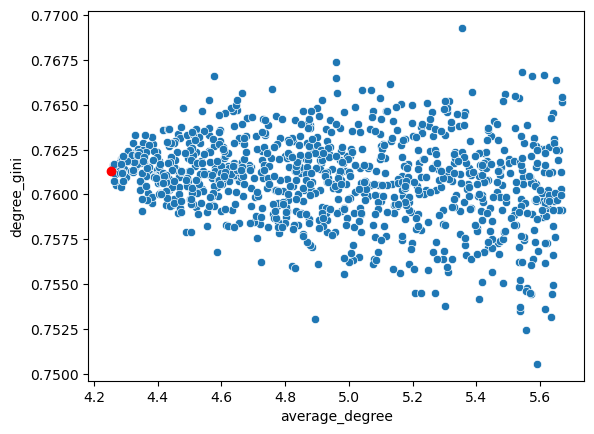

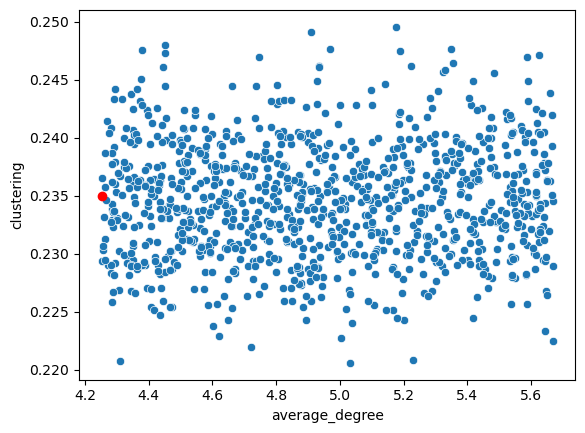

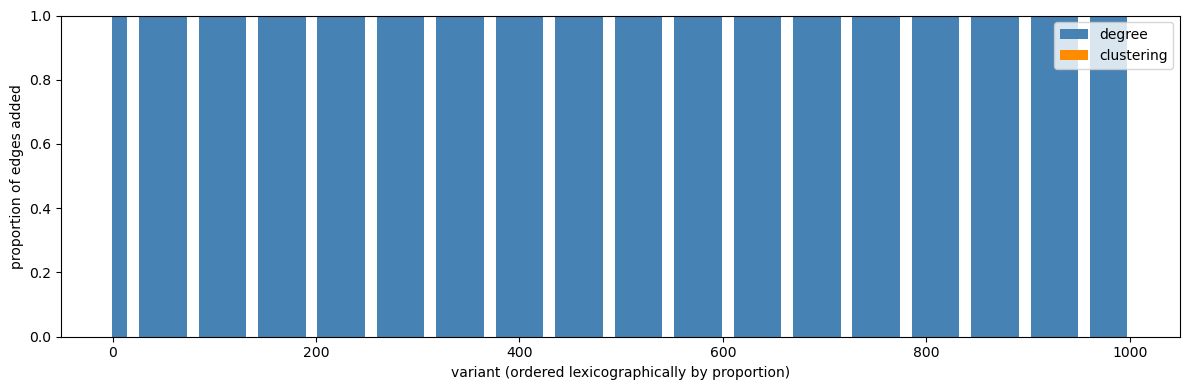

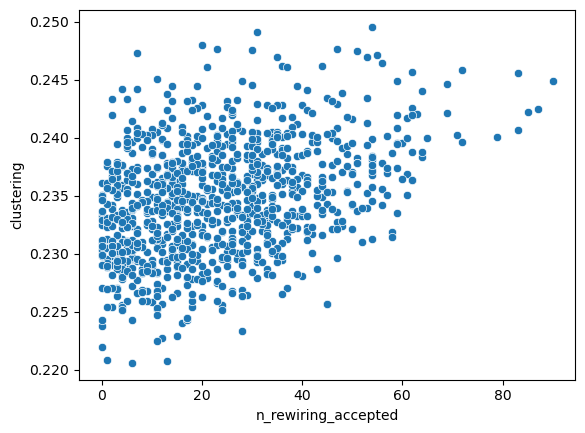

No isolates check. The result should be: True
True


In [ ]:
test_densify(
    tobacco_net, 
    p_conditional=0.5, 
    interim_clustering=False, 
    rewiring_tolerance=0.001, 
    max_post_rewires=1_000, 
    n_variants=1_000,
    max_p_edges=1/3,
    target_clustering_std=0.005,
)

Progress:   0%|          | 0/1000 [00:00<?, ?it/s]

Pearson correlations. The result should be: all weak (except diagonal)
--------------------------------------------------


,average_degree,degree_gini,clustering
average_degree,1.000000,-0.107554,-0.014907
degree_gini,-0.107554,1.000000,-0.006918
clustering,-0.014907,-0.006918,1.000000


,average_degree,degree_gini,clustering
average_degree,strong,weak,weak
degree_gini,weak,strong,weak
clustering,weak,weak,strong


VIF. The result should be: all minimal multicollinearity
--------------------------------------------------


,variable,VIF,VIF interpretation
1,average_degree,1.011954,minimal multicollinearity
2,degree_gini,1.011778,minimal multicollinearity
3,clustering,1.000296,minimal multicollinearity


Scatterplots. Figure should not indicate any relation between the network features.


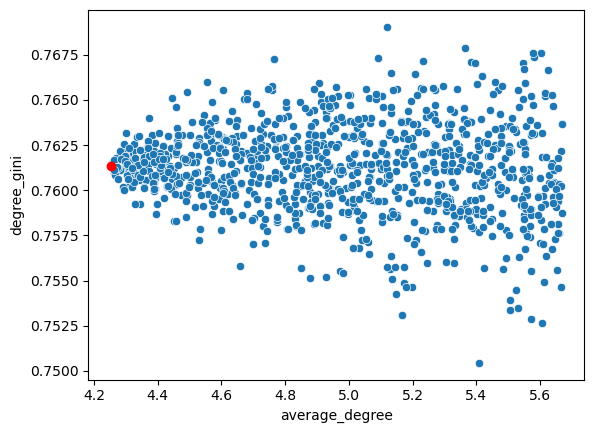

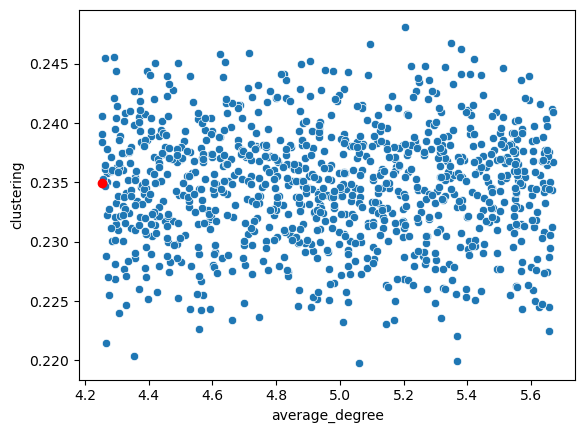

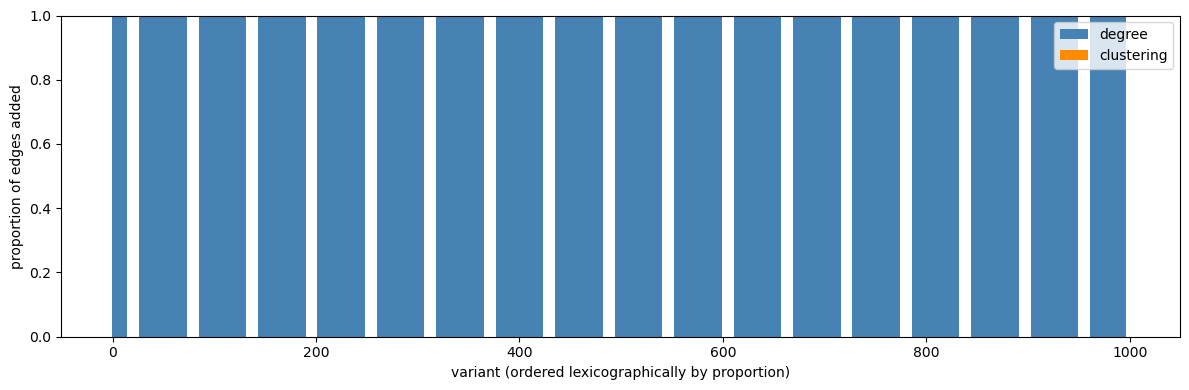

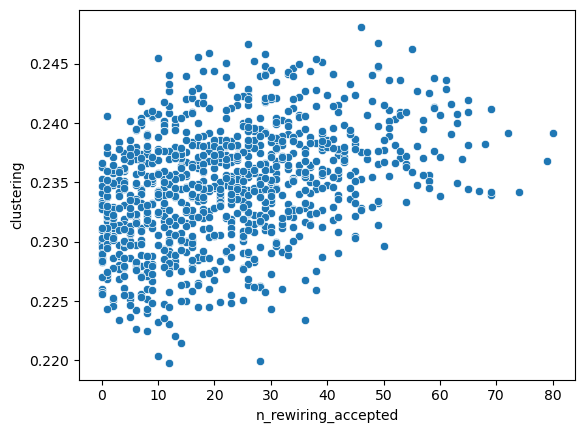

No isolates check. The result should be: True
True


In [ ]:
test_densify(
    tobacco_net, 
    p_conditional=0.55, 
    interim_clustering=False, 
    rewiring_tolerance=0.001, 
    max_post_rewires=1_000, 
    n_variants=1_000,
    max_p_edges=1/3,
    target_clustering_std=0.005,
)

Progress:   0%|          | 0/1000 [00:00<?, ?it/s]

Pearson correlations. The result should be: all weak (except diagonal)
--------------------------------------------------


,average_degree,degree_gini,clustering
average_degree,1.000000,-0.088789,-0.034876
degree_gini,-0.088789,1.000000,0.002702
clustering,-0.034876,0.002702,1.000000


,average_degree,degree_gini,clustering
average_degree,strong,weak,weak
degree_gini,weak,strong,weak
clustering,weak,weak,strong


VIF. The result should be: all minimal multicollinearity
--------------------------------------------------


,variable,VIF,VIF interpretation
1,average_degree,1.009166,minimal multicollinearity
2,degree_gini,1.007946,minimal multicollinearity
3,clustering,1.001218,minimal multicollinearity


Scatterplots. Figure should not indicate any relation between the network features.


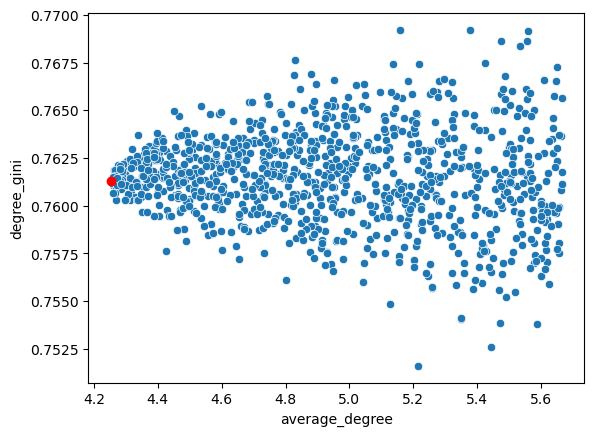

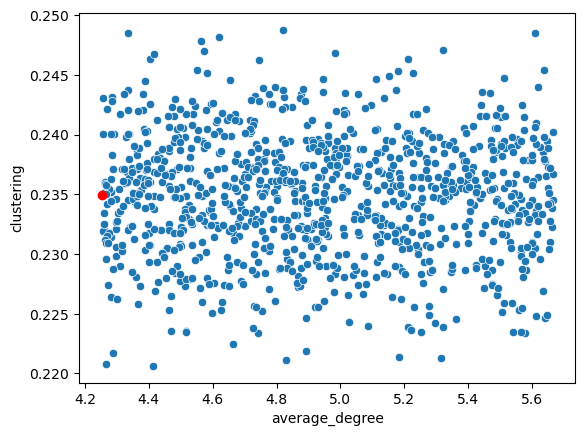

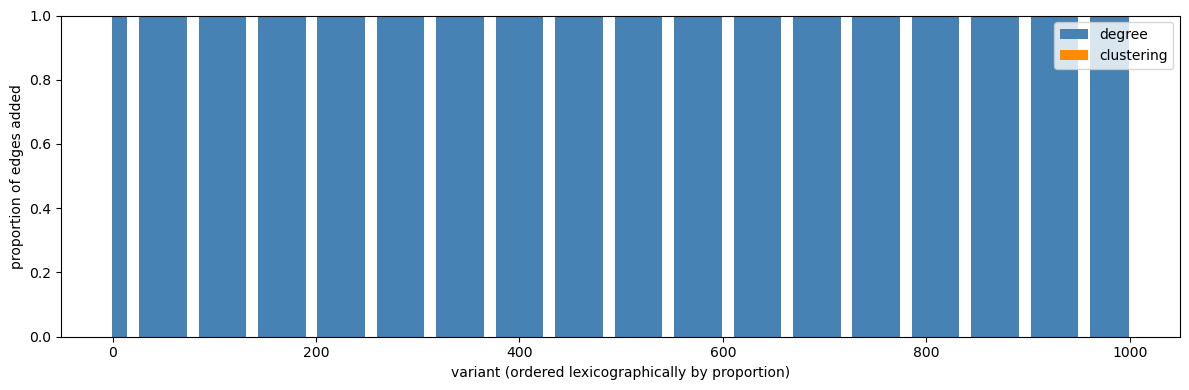

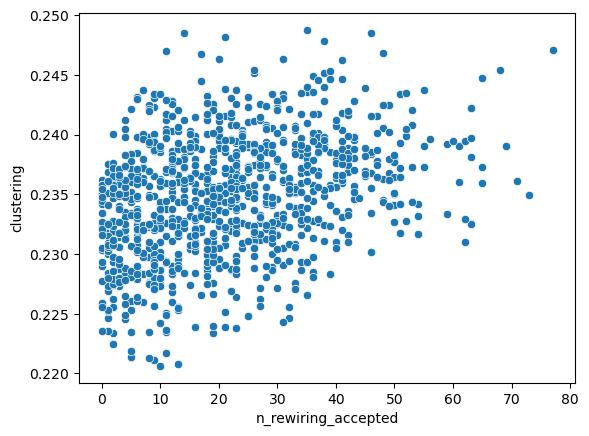

No isolates check. The result should be: True
True


In [ ]:
test_densify(
    tobacco_net, 
    p_conditional=0.6, 
    interim_clustering=False, 
    rewiring_tolerance=0.001, 
    max_post_rewires=1_000, 
    n_variants=1_000,
    max_p_edges=1/3,
    target_clustering_std=0.005,
)

Progress:   0%|          | 0/1000 [00:00<?, ?it/s]

Pearson correlations. The result should be: all weak (except diagonal)
--------------------------------------------------


,average_degree,degree_gini,clustering
average_degree,1.000000,-0.012124,-0.004873
degree_gini,-0.012124,1.000000,0.024081
clustering,-0.004873,0.024081,1.000000


,average_degree,degree_gini,clustering
average_degree,strong,weak,weak
degree_gini,weak,strong,weak
clustering,weak,weak,strong


VIF. The result should be: all minimal multicollinearity
--------------------------------------------------


,variable,VIF,VIF interpretation
1,average_degree,1.000168,minimal multicollinearity
2,degree_gini,1.000725,minimal multicollinearity
3,clustering,1.000601,minimal multicollinearity


Scatterplots. Figure should not indicate any relation between the network features.


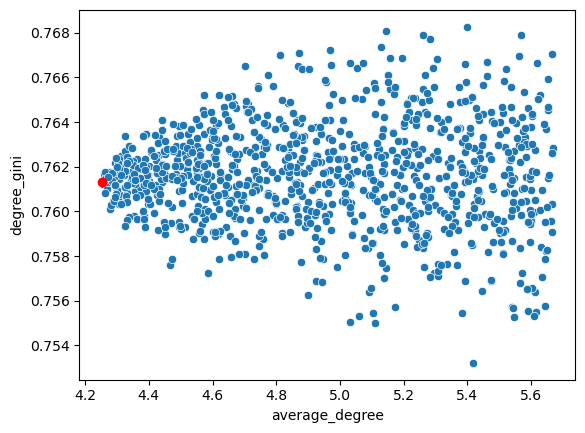

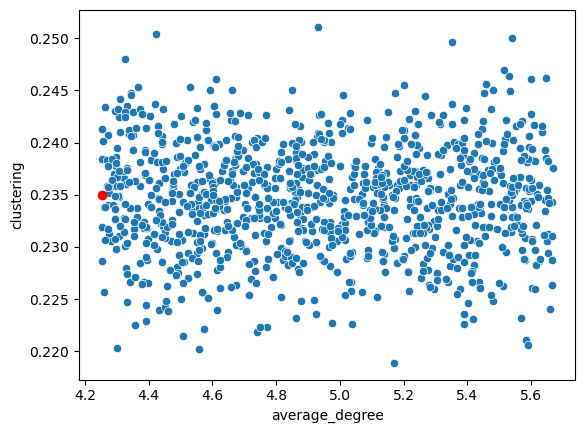

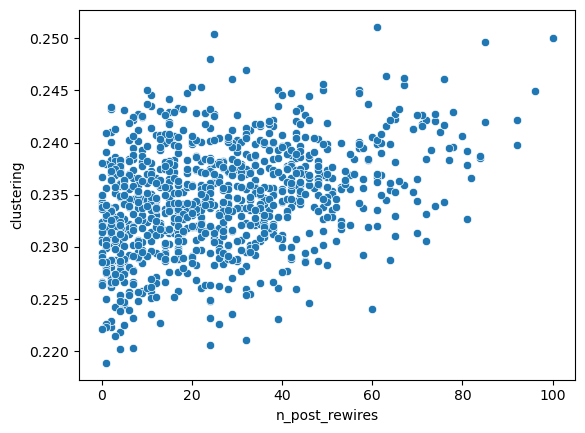

No isolates check. The result should be: True
True


In [13]:
test_densify(
    tobacco_net, 
    p_conditional=0.6, 
    interim_clustering=False, 
    rewiring_tolerance=0.001, 
    max_post_rewires=1_000, 
    n_variants=1_000,
    max_p_edges=1/3,
    target_clustering_std=0.005,
)

### Equalize

Progress:   0%|          | 0/1000 [00:00<?, ?it/s]

Pearson correlations. The result should be: all weak (except diagonal)
--------------------------------------------------


,degree_gini,clustering
degree_gini,1.000000,0.211586
clustering,0.211586,1.000000


,degree_gini,clustering
degree_gini,strong,weak
clustering,weak,strong


VIF. The result should be: all minimal multicollinearity
--------------------------------------------------


,variable,VIF,VIF interpretation
1,degree_gini,1.046867,minimal multicollinearity
2,clustering,1.046867,minimal multicollinearity


Scatterplot. Figure should not indicate any relation between the network features.


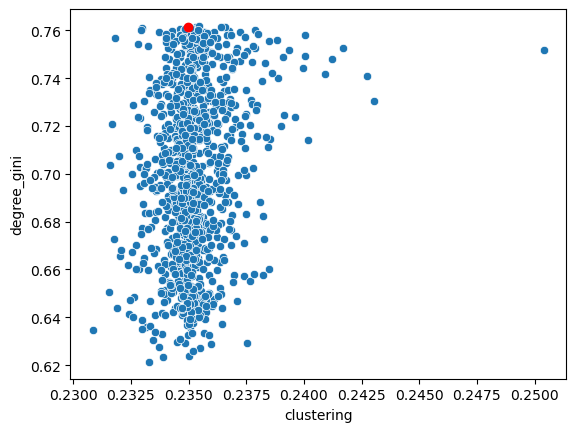

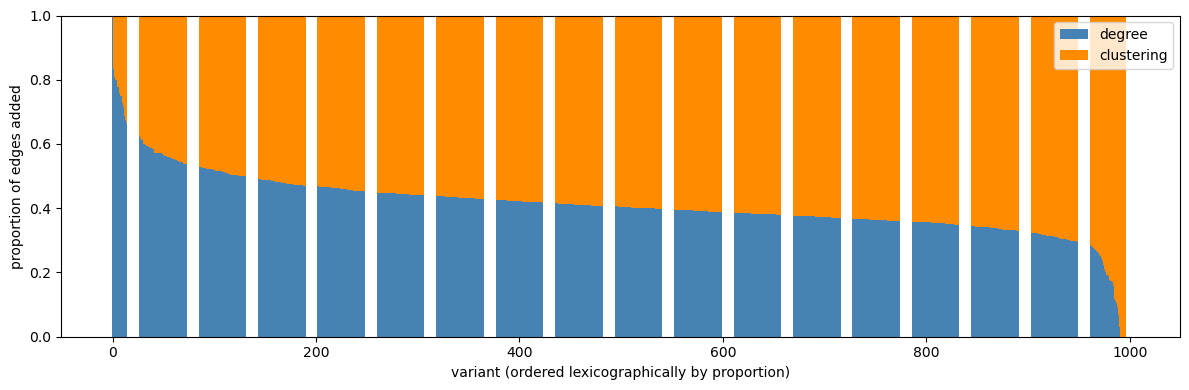

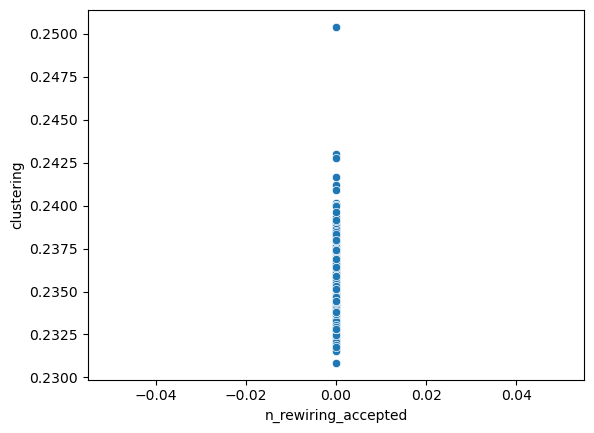

No isolates check. The result should be: True
True


In [ ]:
test_equalize(
    tobacco_net, 
    p_conditional=0.5, 
    interim_clustering=True,
    max_post_rewires=0,
    n_variants=1_000,
)

Progress:   0%|          | 0/1000 [00:00<?, ?it/s]

Pearson correlations. The result should be: all weak (except diagonal)
--------------------------------------------------


,degree_gini,clustering
degree_gini,1.000000,-0.025302
clustering,-0.025302,1.000000


,degree_gini,clustering
degree_gini,strong,weak
clustering,weak,strong


VIF. The result should be: all minimal multicollinearity
--------------------------------------------------


,variable,VIF,VIF interpretation
1,degree_gini,1.000641,minimal multicollinearity
2,clustering,1.000641,minimal multicollinearity


Scatterplot. Figure should not indicate any relation between the network features.


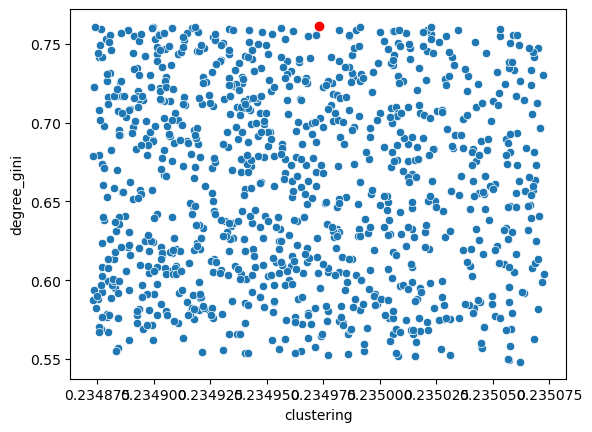

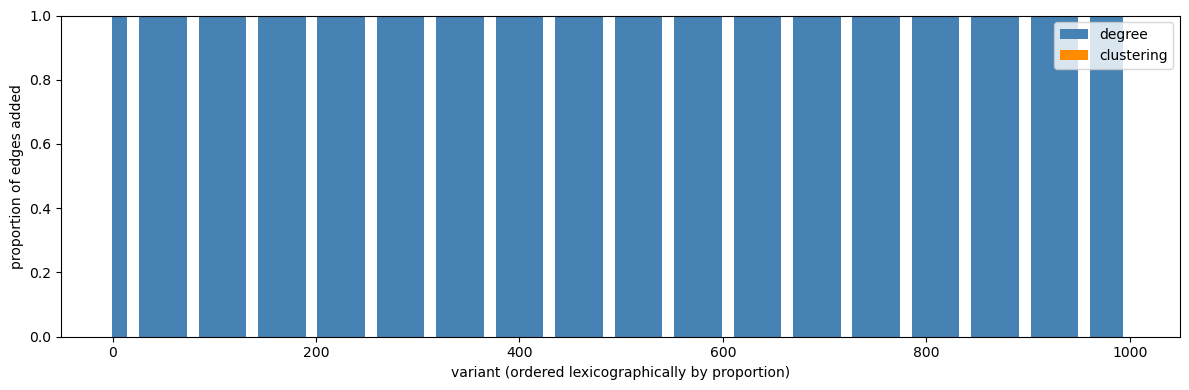

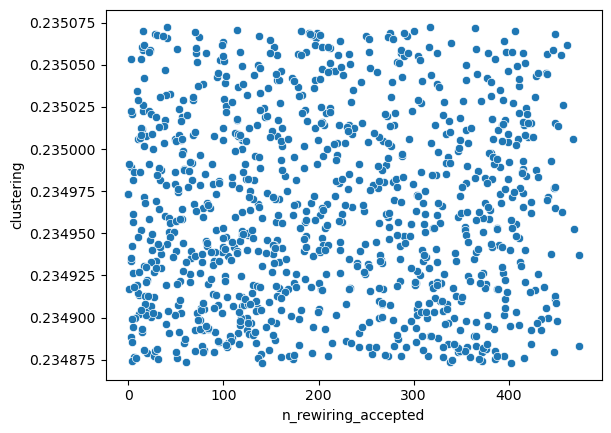

No isolates check. The result should be: True
True


In [ ]:
test_equalize(
    tobacco_net, 
    p_conditional=0.6,
    interim_clustering=False, 
    rewiring_tolerance=0.0001, 
    max_post_rewires=100_000, 
    n_variants=1_000,
    max_p_edges=1/3,
    target_clustering_std=0.005,
)

# Archive

In [ ]:
test_equalize(net, 1_000)

Note: Runtime is approximately 10 minutes.

In [ ]:
df_equalize = generate_variant_df(net, "equalize", 1_000)

The cell below determines multicollinearity by calculating the VIFs and Pearson correlations. The result should be:

- Pearson correlations: all weak (except diagonal)
- VIF: all minimal multicollinearity

In [ ]:
network_features = ["degree_gini",'clustering']
correlations = compute_correlations(df_equalize, columns_corr=network_features)
compute_vif(df_equalize, columns_corr=network_features)

If desired, one can inspect the following scatterplot, which should not indicate any relation between the network features.

In [ ]:
sns.scatterplot(df_equalize, x="clustering", y="degree_gini")

The cell below checks that there are no isolates. The result should be `True`. 

In [ ]:
print(all(x == 0 for x in df_equalize["n_isolates"]))

In [ ]:
test_densify(net, 1_000)